In [1]:
import torch
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

print("Libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")


Libraries loaded successfully!
PyTorch version: 2.10.0+cu126


In [2]:
# Load pre-trained ResNet-18 model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.eval()  # Set to evaluation mode

# Load ImageNet class labels
IMAGENET_LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(IMAGENET_LABELS_URL)
labels = response.text.strip().split("\n")

print(f"Model loaded! It can classify images into {len(labels)} categories.")
print("Some example categories:")
print(f" - {labels[207]} (index 207)")
print(f" - {labels[208]} (index 208)")
print(f" - {labels[281]} (index 281)")
print(f" - {labels[985]} (index 985)")


2.0%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\betha/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Model loaded! It can classify images into 1000 categories.
Some example categories:
 - golden retriever (index 207)
 - Labrador retriever (index 208)
 - tabby (index 281)
 - daisy (index 985)


In [19]:
images = {}

print("Loading images...\n")

animal_images = {
    "lion": "https://upload.wikimedia.org/wikipedia/commons/7/73/Lion_waiting_in_Namibia.jpg",
    "elephant": "https://upload.wikimedia.org/wikipedia/commons/3/37/African_Bush_Elephant.jpg",
    "frog": "https://upload.wikimedia.org/wikipedia/commons/4/4d/Frogs_life.jpg"
}

headers = {"User-Agent": "Mozilla/5.0"}

for name, url in animal_images.items():
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content)).convert("RGB")
        images[name] = {
            "original": img,
            "display": preprocess_display(img),
            "tensor": preprocess(img).unsqueeze(0)
        }

        class_id, prob, class_name = get_prediction(model, images[name]["tensor"])
        print(
            f"Loaded {name}: classified as '{class_name}' "
            f"({prob*100:.1f}% confidence)"
        )

    except Exception as e:
        print(f"Failed to load {name}: {e}")


Loading images...

Loaded lion: classified as 'lion' (100.0% confidence)
Loaded elephant: classified as 'African elephant' (58.7% confidence)
Loaded frog: classified as 'bullfrog' (71.9% confidence)


In [1]:
''' Probing Test 1: Canonical Animal Classification (Lion)
**Purpose:** Evaluate model confidence on a clean, in-distribution ImageNet example.  
**Observation:** The model classified the lion with extremely high confidence (≈100%), indicating strong performance on prototypical inputs. '''


' Probing Test 1: Canonical Animal Classification (Lion)\n**Purpose:** Evaluate model confidence on a clean, in-distribution ImageNet example.  \n**Observation:** The model classified the lion with extremely high confidence (≈100%), indicating strong performance on prototypical inputs. '

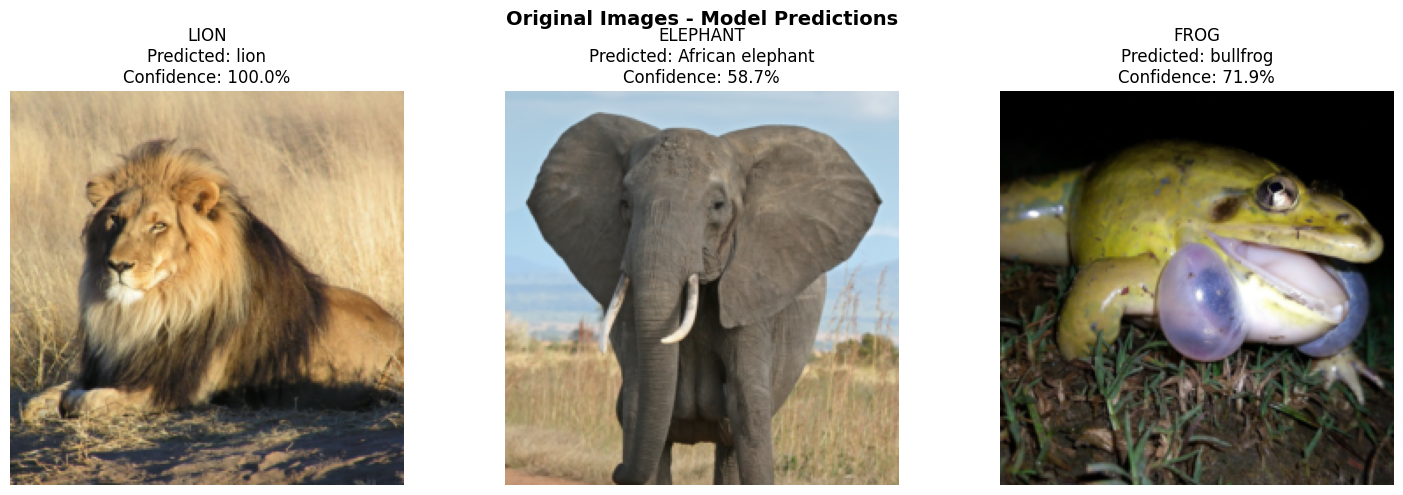

In [20]:
fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

for idx, (name, data) in enumerate(images.items()):
    class_id, prob, class_name = get_prediction(model, data['tensor'])

    ax = axes[idx] if len(images) > 1 else axes
    ax.imshow(data['display'])
    ax.set_title(
        f"{name.upper()}\n"
        f"Predicted: {class_name}\n"
        f"Confidence: {prob*100:.1f}%"
    )
    ax.axis("off")

plt.suptitle("Original Images - Model Predictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [21]:
def pgd_targeted_attack(
    model,
    image_tensor,
    target_class,
    epsilon=0.03,
    alpha=0.005,
    num_steps=100
):
    """
    Perform a targeted PGD attack to make the model predict target_class.

    Args:
        model: The neural network
        image_tensor: Input image tensor (normalized)
        target_class: The class we want the model to predict
        epsilon: Maximum perturbation allowed (L-infinity bound)
        alpha: Step size for each iteration
        num_steps: Number of attack iterations

    Returns:
        adversarial image tensor, perturbation
    """

    # Clone the image
    original = image_tensor.clone().detach()
    adv_image = image_tensor.clone().detach().requires_grad_(True)
    target = torch.tensor([target_class])

    for step in range(num_steps):
        # Forward pass
        output = model(adv_image)

        # Check if we've succeeded
        pred = output.argmax(dim=1).item()
        if pred == target_class:
            prob = F.softmax(output, dim=1)[0, target_class].item()
            if prob > 0.9:  # High confidence success
                print(
                    f"Success at step {step+1}! "
                    f"Target confidence: {prob*100:.1f}%"
                )
                break

        # Compute loss — minimize cross-entropy toward target class
        loss = F.cross_entropy(output, target)

        # Backward pass
        model.zero_grad()
        loss.backward()

        # PGD step
        with torch.no_grad():
            # Take step that decreases loss (increases target probability)
            adv_image = adv_image - alpha * adv_image.grad.sign()

            # Project back to epsilon ball around original image
            perturbation = torch.clamp(
                adv_image - original,
                min=-epsilon,
                max=epsilon
            )
            adv_image = original + perturbation

        # Re-enable gradients
        adv_image = adv_image.detach().requires_grad_(True)

        # Print progress every 25 steps
        if (step + 1) % 25 == 0:
            with torch.no_grad():
                probs = F.softmax(model(adv_image), dim=1)
                target_prob = probs[0, target_class].item()
                current_pred = probs.argmax().item()
                print(
                    f"Step {step+1}: "
                    f"Target prob = {target_prob*100:.1f}%, "
                    f"Current prediction = {labels[current_pred]}"
                )

    perturbation = adv_image.detach() - original
    return adv_image.detach(), perturbation


print("Attack function defined!")


Attack function defined!


In [ ]:
# Target: Make the lion look like a tabby cat (class 281)
TARGET_CLASS = 281  # tabby cat

print(f"Target class: {labels[TARGET_CLASS]}")
print("\nAttacking the lion image...\n")

lion_tensor = images['lion']['tensor']

adv_lion, lion_perturbation = pgd_targeted_attack(
    model,
    lion_tensor,
    TARGET_CLASS,
    epsilon=0.03,
    num_steps=100
)

print("\nAttack complete!")

Target class: tabby

Attacking the lion image...

Success at step 7! Target confidence: 94.0%

Attack complete!


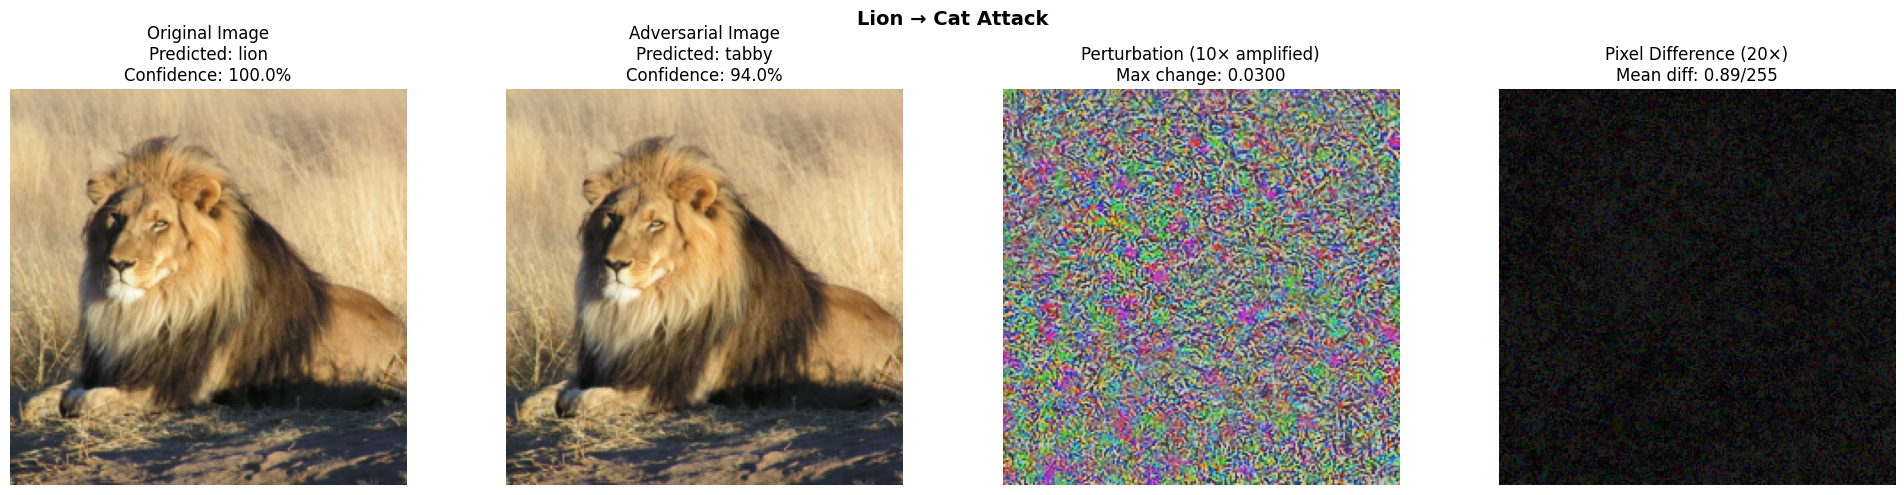


ATTACK SUMMARY
Original prediction: lion (100.0%)
Adversarial prediction: tabby (94.0%)
Maximum pixel change: 7.65/255 (3.0%)


In [25]:
def tensor_to_image(tensor):
    """Convert a normalized tensor back to a displayable image."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor.squeeze(0) * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def visualize_attack(
    original_tensor,
    adversarial_tensor,
    perturbation,
    title="Attack Visualization"
):
    """Visualize original image, adversarial image, and perturbation."""

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Original image
    orig_class, orig_prob, orig_name = get_prediction(model, original_tensor)
    axes[0].imshow(tensor_to_image(original_tensor))
    axes[0].set_title(
        f"Original Image\n"
        f"Predicted: {orig_name}\n"
        f"Confidence: {orig_prob*100:.1f}%",
        fontsize=12
    )
    axes[0].axis("off")

    # Adversarial image
    adv_class, adv_prob, adv_name = get_prediction(model, adversarial_tensor)
    axes[1].imshow(tensor_to_image(adversarial_tensor))
    axes[1].set_title(
        f"Adversarial Image\n"
        f"Predicted: {adv_name}\n"
        f"Confidence: {adv_prob*100:.1f}%",
        fontsize=12
    )
    axes[1].axis("off")

    # Perturbation (amplified for visibility)
    pert_vis = perturbation.squeeze(0).permute(1, 2, 0).numpy()
    pert_amplified = pert_vis * 10 + 0.5  # amplify + center
    axes[2].imshow(pert_amplified.clip(0, 1))
    axes[2].set_title(
        f"Perturbation (10× amplified)\n"
        f"Max change: {perturbation.abs().max().item():.4f}",
        fontsize=12
    )
    axes[2].axis("off")

    # Side-by-side pixel difference
    orig_img = tensor_to_image(original_tensor)
    adv_img = tensor_to_image(adversarial_tensor)
    diff = np.abs(orig_img - adv_img)
    axes[3].imshow(diff * 20)  # amplify difference
    axes[3].set_title(
        f"Pixel Difference (20×)\n"
        f"Mean diff: {diff.mean()*255:.2f}/255",
        fontsize=12
    )
    axes[3].axis("off")

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n" + "=" * 60)
    print("ATTACK SUMMARY")
    print("=" * 60)
    print(f"Original prediction: {orig_name} ({orig_prob*100:.1f}%)")
    print(f"Adversarial prediction: {adv_name} ({adv_prob*100:.1f}%)")
    print(
        f"Maximum pixel change: "
        f"{perturbation.abs().max().item()*255:.2f}/255 "
        f"({perturbation.abs().max().item()*100:.1f}%)"
    )
    print("=" * 60)


# Run visualization for dog → cat attack
visualize_attack(
    lion_tensor,
    adv_lion,
    lion_perturbation,
    title="Lion → Cat Attack"
)


Testing different epsilon values...

(Smaller epsilon = less visible perturbation, but harder to fool the model)


--- Epsilon = 0.01 ---
Step 25: Target prob = 18.6%, Current prediction = lion
Step 50: Target prob = 19.9%, Current prediction = lion
Step 75: Target prob = 20.8%, Current prediction = lion
Step 100: Target prob = 20.8%, Current prediction = lion

--- Epsilon = 0.02 ---
Success at step 9! Target confidence: 92.3%

--- Epsilon = 0.03 ---
Success at step 6! Target confidence: 92.0%

--- Epsilon = 0.05 ---
Success at step 5! Target confidence: 97.7%


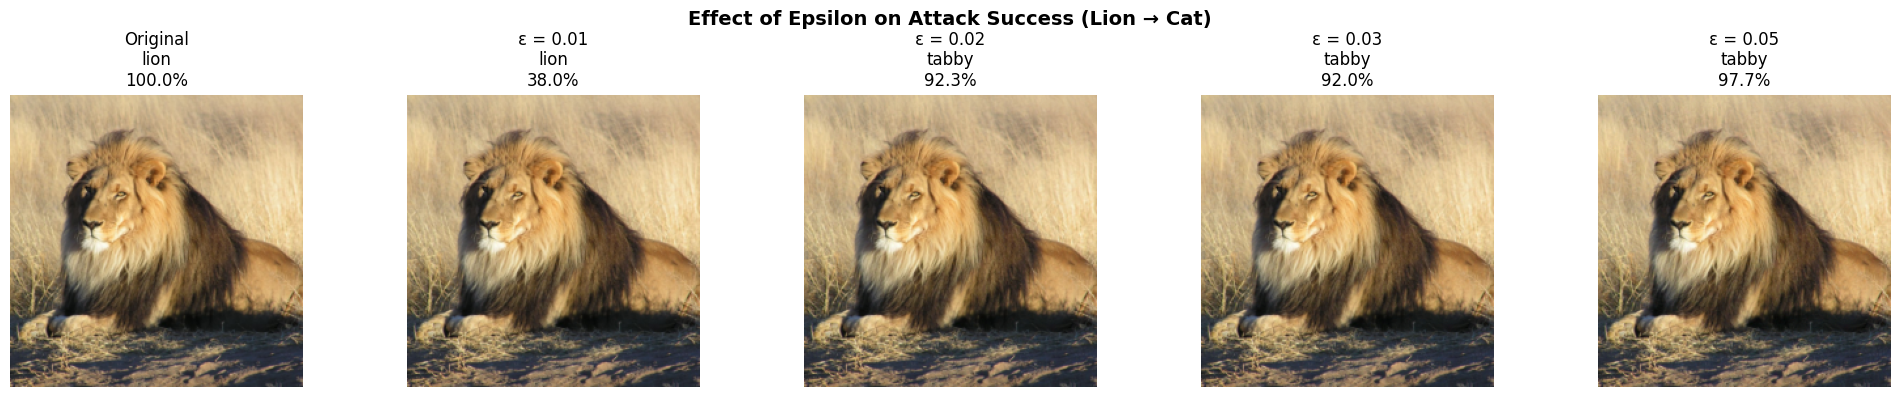

In [27]:
epsilons = [0.01, 0.02, 0.03, 0.05]
results = []

print("Testing different epsilon values...\n")
print("(Smaller epsilon = less visible perturbation, but harder to fool the model)\n")

for eps in epsilons:
    print(f"\n--- Epsilon = {eps} ---")
    adv, pert = pgd_targeted_attack(model, lion_tensor, 281, epsilon=eps, alpha=eps/4, num_steps=100)
    _, prob, name = get_prediction(model, adv)
    results.append({
        'epsilon': eps,
        'adversarial': adv,
        'prediction': name,
        'confidence': prob
    })

# Visualize all results
fig, axes = plt.subplots(1, len(epsilons) + 1, figsize=(20, 4))

# Original
_, orig_prob, orig_name = get_prediction(model, lion_tensor)
axes[0].imshow(tensor_to_image(lion_tensor))
axes[0].set_title(f"Original\n{orig_name}\n{orig_prob*100:.1f}%")
axes[0].axis('off')

# Each epsilon result
for idx, result in enumerate(results):
    axes[idx + 1].imshow(tensor_to_image(result['adversarial']))
    axes[idx + 1].set_title(f"ε = {result['epsilon']}\n{result['prediction']}\n{result['confidence']*100:.1f}%")
    axes[idx + 1].axis('off')

plt.suptitle("Effect of Epsilon on Attack Success (Lion → Cat)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()